# Phase 1 — Special Constraint Decomposer: Test Notebook

This notebook validates `src/hybrid/special_constraint_decomposer.py` across:
1. **Unit tests** — helper functions (`_merge_slots`, `_UnionFind`, checkers)
2. **Partition tests** — every class appears in exactly one of {fixed, community, free}
3. **Community correctness** — every community's constraints are fully covered by its class set
4. **Constraint checker tests** — `check_special_constraints` on known-good and known-bad assignments
5. **Cross-instance statistics** — community sizes, class distribution across all instances

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.utils.dataReader import PSTTReader
from src.hybrid.special_constraint_decomposer import (
    SpecialConstraintDecomposer, Community, ClassificationResult,
    _parse_constraint_type, _is_special,
    _merge_slots, _UnionFind,
    _check_max_days, _check_max_day_load, _check_max_breaks, _check_max_block,
    SPECIAL_TYPES,
)

import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


---
## 1. Unit Tests — Helper Functions

In [2]:
# ── _parse_constraint_type ──────────────────────────────────────────────────
cases = [
    ('MaxDays(3)',      ('MaxDays',    '3')),
    ('MaxDayLoad(84)',  ('MaxDayLoad', '84')),
    ('MaxBreaks(1,6)',  ('MaxBreaks',  '1,6')),
    ('MaxBlock(24,6)',  ('MaxBlock',   '24,6')),
    ('NotOverlap',      ('NotOverlap', None)),
    ('SameTime',        ('SameTime',   None)),
    ('WorkDay(24)',     ('WorkDay',    '24')),
]
for type_str, expected in cases:
    got = _parse_constraint_type(type_str)
    assert got == expected, f'{type_str}: expected {expected}, got {got}'
print('_parse_constraint_type  OK  ({} cases)'.format(len(cases)))

# ── _is_special ────────────────────────────────────────────────────────────
for t in ['MaxDays(3)', 'MaxDayLoad(84)', 'MaxBreaks(1,6)', 'MaxBlock(24,6)']:
    assert _is_special(t), f'{t} should be special'
for t in ['NotOverlap', 'SameTime', 'WorkDay(24)', 'MinGap(6)', 'Precedence']:
    assert not _is_special(t), f'{t} should NOT be special'
print('_is_special             OK')

_parse_constraint_type  OK  (7 cases)
_is_special             OK


In [3]:
# ── _merge_slots ────────────────────────────────────────────────────────────
merge_cases = [
    # (slots,             gap, expected)
    ([(0,2),(3,2)],       1,   [(0,5)]),        # gap=1 merges
    ([(0,2),(4,2)],       1,   [(0,2),(4,2)]),  # gap=2 > threshold=1
    ([(5,2),(0,2)],       0,   [(0,2),(5,2)]),  # unsorted input
    ([(0,10),(5,10)],     0,   [(0,15)]),        # overlapping
    ([],                  5,   []),             # empty
    ([(3,4)],             5,   [(3,4)]),         # single slot
    ([(0,2),(3,2),(6,2)], 1,   [(0,8)]),         # three merge into one
    ([(0,2),(4,2),(8,2)], 1,   [(0,2),(4,2),(8,2)]),  # no merges
]
for slots, gap, expected in merge_cases:
    got = _merge_slots(slots, gap)
    assert got == expected, f'slots={slots} gap={gap}: expected {expected}, got {got}'
print(f'_merge_slots            OK  ({len(merge_cases)} cases)')

_merge_slots            OK  (8 cases)


In [4]:
# ── _UnionFind ──────────────────────────────────────────────────────────────
uf = _UnionFind()
for x in ['a','b','c','d','e']:
    uf.add(x)

uf.union('a','b')
uf.union('b','c')
assert uf.find('a') == uf.find('b') == uf.find('c'), 'a,b,c should be in same group'
assert uf.find('d') != uf.find('a'), 'd should be isolated'
assert uf.find('e') != uf.find('a'), 'e should be isolated'
assert uf.find('d') != uf.find('e'), 'd and e should be separate'

uf.union('d','e')
assert uf.find('d') == uf.find('e')
groups = uf.groups()
assert len(groups) == 2, f'Expected 2 groups, got {len(groups)}'
sizes = sorted(len(v) for v in groups.values())
assert sizes == [2, 3], f'Expected group sizes [2,3], got {sizes}'
print('_UnionFind              OK')

_UnionFind              OK


---
## 2. Unit Tests — Constraint Checkers

All time_bits tuples use the format `(weeks_bits, days_bits, start, length)` with:
- `weeks_bits`: binary string, '1' = active week
- `days_bits`:  binary string (7 chars), '1' = active day (0=Mon … 6=Sun)
- `start`:  slot index within a day (288 slots/day, 5-min each)
- `length`: number of consecutive slots

In [5]:
# Convenience: all weeks active, specific day
def tb(day_idx, start, length, nw=6):
    """Build a time_bits tuple: active every week, on one specific day."""
    weeks = '1' * nw
    days  = '0' * day_idx + '1' + '0' * (6 - day_idx)  # 7-char string
    return (weeks, days, start, length)

MON, TUE, WED, THU, FRI = 0, 1, 2, 3, 4
NW, ND = 6, 7

In [6]:
# ── MaxDays ─────────────────────────────────────────────────────────────────
# Two classes on Mon+Tue → 2 distinct days
cbt = {'c1': tb(MON, 48, 12), 'c2': tb(TUE, 60, 12)}
assert     _check_max_days(cbt, '2', NW, ND), 'MaxDays(2): 2 days should pass'
assert not _check_max_days(cbt, '1', NW, ND), 'MaxDays(1): 2 days should fail'

# All three on same day (Mon) → 1 day
cbt_same = {'c1': tb(MON,10,6), 'c2': tb(MON,20,6), 'c3': tb(MON,30,6)}
assert     _check_max_days(cbt_same, '1', NW, ND)
assert not _check_max_days(cbt_same, '0', NW, ND)

# Mon+Wed+Fri → 3 days
cbt3 = {'c1': tb(MON,48,12), 'c2': tb(WED,48,12), 'c3': tb(FRI,48,12)}
assert     _check_max_days(cbt3, '3', NW, ND)
assert not _check_max_days(cbt3, '2', NW, ND)
print('_check_max_days         OK')

_check_max_days         OK


In [7]:
# ── MaxDayLoad ───────────────────────────────────────────────────────────────
# Two classes on the SAME day, total load = 12+12 = 24
cbt_same = {'c1': tb(MON, 48, 12), 'c2': tb(MON, 60, 12)}
assert     _check_max_day_load(cbt_same, '24', NW, ND), 'load=24 ≤ 24'
assert not _check_max_day_load(cbt_same, '23', NW, ND), 'load=24 > 23'

# Classes on different days: max load per day = 12
cbt_diff = {'c1': tb(MON, 48, 12), 'c2': tb(TUE, 48, 12)}
assert     _check_max_day_load(cbt_diff, '12', NW, ND)
assert not _check_max_day_load(cbt_diff, '11', NW, ND)

# Three classes on Mon: 6+6+6=18
cbt3 = {'c1': tb(MON,10,6), 'c2': tb(MON,20,6), 'c3': tb(MON,30,6)}
assert     _check_max_day_load(cbt3, '18', NW, ND)
assert not _check_max_day_load(cbt3, '17', NW, ND)
print('_check_max_day_load     OK')

_check_max_day_load     OK


In [8]:
# ── MaxBreaks ────────────────────────────────────────────────────────────────
# Two non-adjacent classes on Mon: gap = 100-60 = 40 slots >> S=6  → 1 break
cbt2 = {'c1': tb(MON, 48, 12), 'c2': tb(MON, 100, 12)}
assert     _check_max_breaks(cbt2, '1,6', NW, ND), 'R=1 breaks: 1 break should pass'
assert not _check_max_breaks(cbt2, '0,6', NW, ND), 'R=0 breaks: 1 break should fail'

# Adjacent classes (gap < S=6): merged into 1 block → 0 breaks
cbt_adj = {'c1': tb(MON, 48, 12), 'c2': tb(MON, 60, 12)}
assert _check_max_breaks(cbt_adj, '0,6', NW, ND), 'adjacent: 0 breaks'

# Three classes on Mon, two separated gaps: 2 breaks
cbt3 = {
    'c1': tb(MON,  48, 12),   # 48–59
    'c2': tb(MON, 100, 12),   # 100–111   gap1=40 > S=6
    'c3': tb(MON, 150, 12),   # 150–161   gap2=38 > S=6
}
assert     _check_max_breaks(cbt3, '2,6', NW, ND), '2 breaks, R=2'
assert not _check_max_breaks(cbt3, '1,6', NW, ND), '2 breaks, R=1'

# Different days: each day has at most 1 class → 0 breaks per day
cbt_days = {'c1': tb(MON, 48, 12), 'c2': tb(TUE, 48, 12)}
assert _check_max_breaks(cbt_days, '0,6', NW, ND)
print('_check_max_breaks       OK')

_check_max_breaks       OK


In [9]:
# ── MaxBlock ─────────────────────────────────────────────────────────────────
# Two adjacent classes on Mon: block length = 12+12 = 24
cbt_adj = {'c1': tb(MON, 48, 12), 'c2': tb(MON, 60, 12)}
assert     _check_max_block(cbt_adj, '24,0', NW, ND), 'block=24, M=24'
assert not _check_max_block(cbt_adj, '23,0', NW, ND), 'block=24, M=23'

# Gap=5 within merge threshold S=5: block = 48 to 65+12=77, length=29
cbt_gap5 = {'c1': tb(MON, 48, 12), 'c2': tb(MON, 65, 12)}  # gap = 65-60 = 5
assert     _check_max_block(cbt_gap5, '29,5', NW, ND), 'merged block=29, M=29'
assert not _check_max_block(cbt_gap5, '28,5', NW, ND), 'merged block=29, M=28'

# Gap=6 exceeds merge threshold S=5: two separate blocks → no block > 12
cbt_gap6 = {'c1': tb(MON, 48, 12), 'c2': tb(MON, 66, 12)}  # gap = 66-60 = 6
assert _check_max_block(cbt_gap6, '12,5', NW, ND), 'gap exceeds S: two blocks of 12'

# Single class: no block with ≥2 members → always pass
cbt_solo = {'c1': tb(MON, 48, 12)}
assert _check_max_block(cbt_solo, '1,0', NW, ND), 'single class always passes'

# Different days: no same-day block with ≥2 members → always pass
cbt_days = {'c1': tb(MON, 48, 12), 'c2': tb(TUE, 48, 12)}
assert _check_max_block(cbt_days, '1,0', NW, ND), 'different days: no multi-class block'
print('_check_max_block        OK')

_check_max_block        OK


---
## 3. Integration Tests on a Single Instance

Using `agh-fal17.xml` — 5081 classes, 178 special constraints, known to produce communities.

In [10]:
INSTANCE = '../data/source/instances/agh-fal17.xml'
reader = PSTTReader(INSTANCE)
decomp = SpecialConstraintDecomposer(reader)
print(decomp.summary())

Problem Name: agh-fal17, Days: 7, Weeks: 18, Slots/Day: 288
=== Special Constraint Decomposer Summary ===
  Total classes   : 5081
  Fixed classes   : 341
  Community classes: 409
  Free classes    : 4331
  Communities     : 31
    Community  26:  185 classes, 114 constraints [MaxBreaks×64, MaxDayLoad×17, MaxDays×33]
    Community   8:   60 classes,  15 constraints [MaxBreaks×7, MaxDays×8]
    Community  12:   25 classes,   7 constraints [MaxBreaks×3, MaxDays×4]
    Community   1:   12 classes,   1 constraints [MaxDays×1]
    Community   7:    9 classes,   1 constraints [MaxDays×1]
    Community  17:    9 classes,   2 constraints [MaxBreaks×1, MaxDays×1]
    Community  19:    9 classes,   2 constraints [MaxBreaks×1, MaxDays×1]
    Community   2:    8 classes,   1 constraints [MaxDays×1]
    Community   3:    8 classes,   1 constraints [MaxDays×1]
    Community  20:    8 classes,   2 constraints [MaxBreaks×1, MaxDays×1]
    Community   4:    7 classes,   1 constraints [MaxDays×1]
    Co

In [11]:
# ── Partition correctness ────────────────────────────────────────────────────
result = decomp.classify_classes()
all_classes = set(reader.classes.keys())

# 1. Union covers every class
union = result.fixed | result.community | result.free
assert union == all_classes, f'Missing classes: {all_classes - union}'

# 2. Disjoint
assert result.fixed & result.community == set(), 'fixed ∩ community must be empty'
assert result.fixed & result.free     == set(), 'fixed ∩ free must be empty'
assert result.community & result.free == set(), 'community ∩ free must be empty'

print(f'Partition OK — {len(all_classes)} classes = '
      f'{len(result.fixed)} fixed + {len(result.community)} community + {len(result.free)} free')

Partition OK — 5081 classes = 341 fixed + 409 community + 4331 free


In [12]:
# ── Community internal consistency ──────────────────────────────────────────
# Every class in a community must be known to the reader
# Every community's constraint's classes must all be in that community
for comm in result.communities:
    # All member classes exist in reader
    for cid in comm.class_ids:
        assert cid in reader.classes, f'Unknown class {cid} in community {comm.id}'

    # All constraint classes are subsets of this community's class_ids
    for cons in comm.constraints:
        missing = set(cons['classes']) - comm.class_ids
        assert not missing, (
            f'Community {comm.id}: constraint {cons["type"]} '
            f'has classes outside community: {missing}'
        )

    # All constraints are indeed special
    for cons in comm.constraints:
        assert _is_special(cons['type']), (
            f'Community {comm.id}: non-special constraint leaked in: {cons["type"]}'
        )

# Communities are disjoint (classes appear in at most one community)
seen = {}
for comm in result.communities:
    for cid in comm.class_ids:
        assert cid not in seen, (
            f'Class {cid} appears in community {seen[cid]} AND {comm.id}'
        )
        seen[cid] = comm.id

print(f'Community consistency   OK — {len(result.communities)} communities, '
      f'{sum(len(c.class_ids) for c in result.communities)} total members')

Community consistency   OK — 31 communities, 417 total members


In [13]:
# ── Fixed assignments ────────────────────────────────────────────────────────
fixed_assignments = decomp.get_fixed_assignments()
assert set(fixed_assignments.keys()) == result.fixed, \
    'get_fixed_assignments() keys must match result.fixed'

# Spot-check: each fixed assignment is a valid (tidx, rid) pair
for cid, (tidx, rid) in fixed_assignments.items():
    cls = reader.classes[cid]
    assert 0 <= tidx < len(cls['time_options']), f'Invalid tidx {tidx} for class {cid}'
    if rid is not None:
        assert rid in reader.rooms, f'Invalid room {rid} for class {cid}'

print(f'Fixed assignments       OK — {len(fixed_assignments)} assignments verified')

Fixed assignments       OK — 341 assignments verified


In [14]:
# ── check_special_constraints ────────────────────────────────────────────────
# Test each community with valid (first-option) assignments and
# check the return type is bool.

all_results = []
for comm in result.communities:
    assignments = {}
    for cid in comm.class_ids:
        cls = reader.classes[cid]
        tidx = 0
        rid  = cls['room_options'][0]['id'] if cls['room_options'] else None
        assignments[cid] = (tidx, rid)
    ok = decomp.check_special_constraints(comm, assignments)
    assert isinstance(ok, bool), f'check_special_constraints must return bool, got {type(ok)}'
    all_results.append(ok)

n_satisfied = sum(all_results)
print(f'check_special_constraints (first-option assignments):')
print(f'  Satisfied : {n_satisfied}/{len(all_results)} communities')
print(f'  Violated  : {len(all_results)-n_satisfied}/{len(all_results)} communities')
print('  (violations are expected — first options are not optimised)')

check_special_constraints (first-option assignments):
  Satisfied : 27/31 communities
  Violated  : 4/31 communities
  (violations are expected — first options are not optimised)


In [15]:
# ── check_special_constraints: empty assignment (partial coverage) ────────────
# Passing an empty dict should not crash; trivially satisfied (nothing assigned)
for comm in result.communities[:3]:
    ok = decomp.check_special_constraints(comm, {})
    assert ok is True, 'Empty assignment must be trivially satisfied'

print('Empty-assignment edge case OK')

Empty-assignment edge case OK


---
## 4. Targeted Constraint Checker Integration Tests

For each special constraint type found in the instance, construct one assignment that **passes** and one that **fails**.

In [16]:
from src.hybrid.special_constraint_decomposer import _parse_constraint_type

def first_assignment(comm, reader):
    """Return {cid: (0, first_room_or_None)} for all classes in community."""
    a = {}
    for cid in comm.class_ids:
        cls = reader.classes[cid]
        rid = cls['room_options'][0]['id'] if cls['room_options'] else None
        a[cid] = (0, rid)
    return a

def last_assignment(comm, reader):
    """Return {cid: (last_tidx, first_room_or_None)} — spreads classes across time."""
    a = {}
    for cid in comm.class_ids:
        cls = reader.classes[cid]
        rid   = cls['room_options'][0]['id'] if cls['room_options'] else None
        tidx  = len(cls['time_options']) - 1
        a[cid] = (tidx, rid)
    return a

# Collect one community per type
type_to_comm = {}
for comm in result.communities:
    for cons in comm.constraints:
        base, _ = _parse_constraint_type(cons['type'])
        if base not in type_to_comm:
            type_to_comm[base] = comm

print('Constraint types found in communities:', sorted(type_to_comm.keys()))

Constraint types found in communities: ['MaxBreaks', 'MaxDayLoad', 'MaxDays']


In [17]:
# For each type: run check with first-option and last-option assignments
# We cannot guarantee which will pass/fail, but we verify:
#   - No exception is raised
#   - Return type is bool

rows = []
for base, comm in sorted(type_to_comm.items()):
    a1 = first_assignment(comm, reader)
    a2 = last_assignment(comm, reader)
    r1 = decomp.check_special_constraints(comm, a1)
    r2 = decomp.check_special_constraints(comm, a2)
    assert isinstance(r1, bool) and isinstance(r2, bool)
    rows.append({
        'Type': base,
        'Community': comm.id,
        'Classes': len(comm.class_ids),
        'Constraints': len(comm.constraints),
        'First-option': 'PASS' if r1 else 'FAIL',
        'Last-option':  'PASS' if r2 else 'FAIL',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

      Type  Community  Classes  Constraints First-option Last-option
 MaxBreaks          0        2            1         PASS        PASS
MaxDayLoad         26      185          114         FAIL        FAIL
   MaxDays          1       12            1         PASS        PASS


---
## 5. Cross-Instance Statistics

In [18]:
import glob, os

instance_paths = sorted(glob.glob('../data/source/**/*.xml', recursive=True))
print(f'Found {len(instance_paths)} instances')

stats = []
for path in instance_paths:
    name = os.path.splitext(os.path.basename(path))[0]
    try:
        r = PSTTReader(path)
        d = SpecialConstraintDecomposer(r)
        res = d.classify_classes()

        # Partition check
        assert (res.fixed | res.community | res.free) == set(r.classes.keys())
        assert not (res.fixed & res.community)
        assert not (res.fixed & res.free)
        assert not (res.community & res.free)

        total = len(r.classes)
        all_special = [c for c in r.distributions.get('hard_constraints',[])
                         + r.distributions.get('soft_constraints',[])
                       if _is_special(c['type'])]
        stats.append({
            'Instance':        name,
            'Classes':         total,
            'Fixed':           len(res.fixed),
            'Community':       len(res.community),
            'Free':            len(res.free),
            'Communities':     len(res.communities),
            'SpecialCons':     len(all_special),
            'Community%':      round(100 * len(res.community) / total, 1) if total else 0,
            'Partition OK':    True,
        })
    except Exception as e:
        stats.append({'Instance': name, 'Error': str(e)})

df_stats = pd.DataFrame(stats)
print(f'Processed: {len(df_stats)} instances')
errors = df_stats[df_stats.get('Error', pd.Series(dtype=str)).notna()] if 'Error' in df_stats.columns else pd.DataFrame()
if len(errors):
    print('Errors:', errors[['Instance','Error']].to_string(index=False))
else:
    print('No errors.')

Found 96 instances
Problem Name: agh-fis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: bet-fal17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: iku-fal17, Days: 7, Weeks: 14, Slots/Day: 288
Problem Name: mary-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: muni-fi-spr16, Days: 7, Weeks: 15, Slots/Day: 288
Problem Name: muni-fsps-spr17, Days: 7, Weeks: 19, Slots/Day: 288
Problem Name: muni-pdf-spr16c, Days: 7, Weeks: 13, Slots/Day: 288
Problem Name: pu-llr-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: tg-fal17, Days: 7, Weeks: 14, Slots/Day: 288
Problem Name: agh-fal17, Days: 7, Weeks: 18, Slots/Day: 288
Problem Name: agh-fis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggos-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-h-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: bet-fal17, Days: 7, Wee

In [19]:
# Partition check: all instances must pass
ok_col = 'Partition OK'
if ok_col in df_stats.columns:
    failed = df_stats[df_stats[ok_col] != True]
    assert len(failed) == 0, f'Partition failed for: {failed["Instance"].tolist()}'
print(f'Partition OK for ALL {len(df_stats)} instances')

Partition OK for ALL 96 instances


In [20]:
# Summary table
display_cols = ['Instance','Classes','Fixed','Community','Free','Communities','SpecialCons','Community%']
available = [c for c in display_cols if c in df_stats.columns]
df_display = df_stats[available].sort_values('Community%', ascending=False)
df_display

,Instance,Classes,Fixed,Community,Free,Communities,SpecialCons,Community%
59,yach-fal17,417,14,199,204,43,45,47.7
89,yach-fal17,417,14,199,204,43,45,47.7
39,yach-fal17,417,14,199,204,43,45,47.7
14,agh-h-spr17,460,2,193,265,5,76,42.0
51,agh-h-spr17,460,2,193,265,5,76,42.0
...,...,...,...,...,...,...,...,...
91,lums-sum17,20,0,0,20,0,0,0.0
92,pu-c8-spr07,2417,489,0,1928,0,0,0.0
93,pu-cs-fal07,174,0,0,174,0,0,0.0
94,pu-llr-spr07,802,266,0,536,0,0,0.0


---
## 6. Visualisations

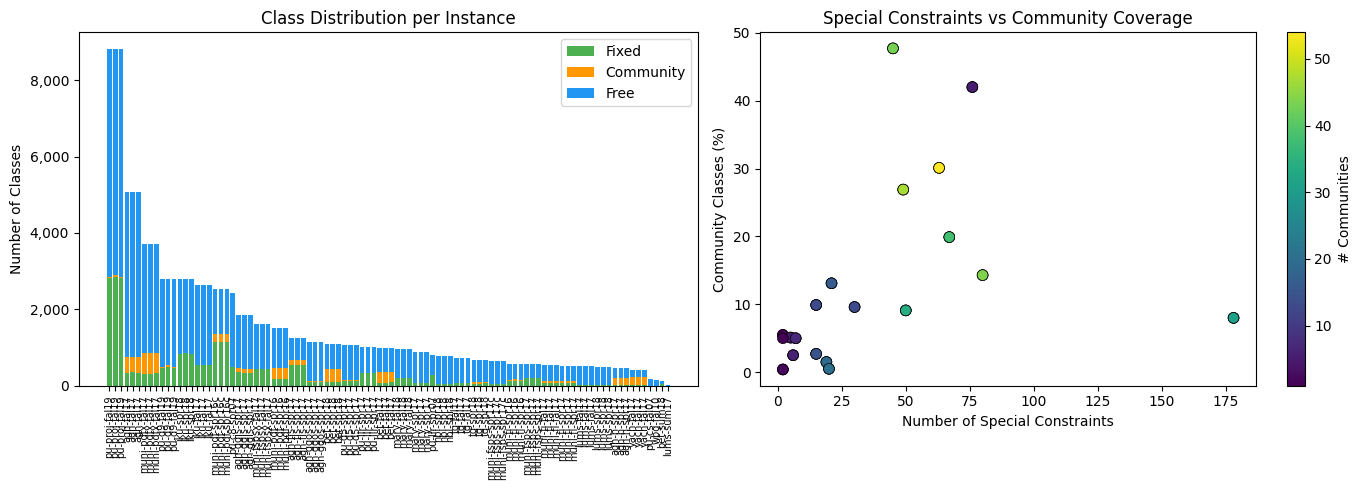

Saved: phase1_class_distribution.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: stacked bar — class distribution per instance ──────────────────────
ax = axes[0]
df_plot = df_stats[available].copy().sort_values('Classes', ascending=False)
instances = df_plot['Instance'].str.replace(r'^(instances|test|early|middle|late)/', '', regex=True)
x = range(len(df_plot))
ax.bar(x, df_plot['Fixed'],     label='Fixed',     color='#4CAF50')
ax.bar(x, df_plot['Community'], label='Community', color='#FF9800',
       bottom=df_plot['Fixed'])
ax.bar(x, df_plot['Free'],      label='Free',      color='#2196F3',
       bottom=df_plot['Fixed'] + df_plot['Community'])
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['Instance'], rotation=90, fontsize=7)
ax.set_ylabel('Number of Classes')
ax.set_title('Class Distribution per Instance')
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

# ── Right: scatter — special constraints vs community classes% ───────────────
ax2 = axes[1]
has_special = df_stats[df_stats.get('SpecialCons', pd.Series(0, index=df_stats.index)) > 0].copy()
sc = ax2.scatter(
    has_special['SpecialCons'],
    has_special['Community%'],
    c=has_special['Communities'],
    cmap='viridis', s=60, edgecolors='k', linewidths=0.5
)
plt.colorbar(sc, ax=ax2, label='# Communities')
ax2.set_xlabel('Number of Special Constraints')
ax2.set_ylabel('Community Classes (%)')
ax2.set_title('Special Constraints vs Community Coverage')

plt.tight_layout()
plt.savefig('phase1_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: phase1_class_distribution.png')

Problem Name: agh-fal17, Days: 7, Weeks: 18, Slots/Day: 288


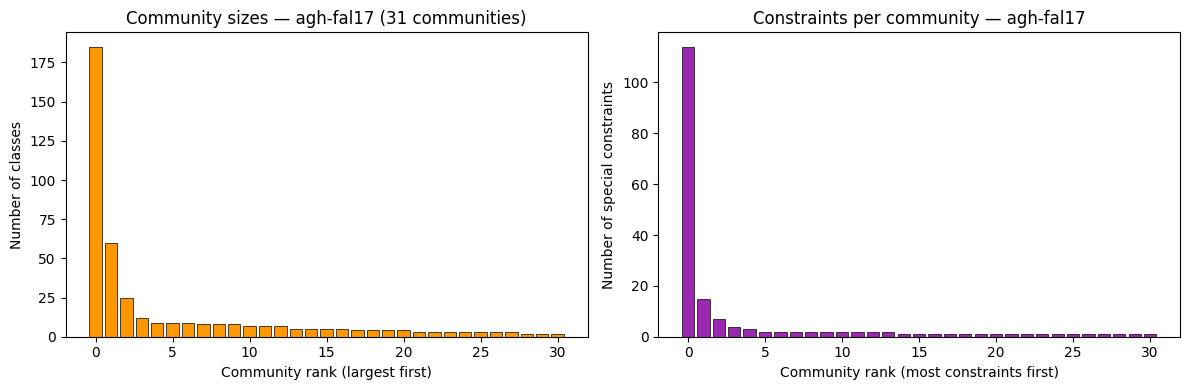

Saved: phase1_community_sizes.png


In [22]:
# ── Community size distribution (agh-fal17) ──────────────────────────────────
reader_big = PSTTReader('../data/source/instances/agh-fal17.xml')
decomp_big = SpecialConstraintDecomposer(reader_big)
result_big = decomp_big.classify_classes()

comm_sizes  = sorted([len(c.class_ids)  for c in result_big.communities], reverse=True)
comm_ncons  = sorted([len(c.constraints) for c in result_big.communities], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(comm_sizes)), comm_sizes, color='#FF9800', edgecolor='k', linewidth=0.5)
axes[0].set_xlabel('Community rank (largest first)')
axes[0].set_ylabel('Number of classes')
axes[0].set_title(f'Community sizes — agh-fal17 ({len(comm_sizes)} communities)')

axes[1].bar(range(len(comm_ncons)), comm_ncons, color='#9C27B0', edgecolor='k', linewidth=0.5)
axes[1].set_xlabel('Community rank (most constraints first)')
axes[1].set_ylabel('Number of special constraints')
axes[1].set_title('Constraints per community — agh-fal17')

plt.tight_layout()
plt.savefig('phase1_community_sizes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: phase1_community_sizes.png')

Problem Name: agh-fis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: bet-fal17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: iku-fal17, Days: 7, Weeks: 14, Slots/Day: 288
Problem Name: mary-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: muni-fi-spr16, Days: 7, Weeks: 15, Slots/Day: 288
Problem Name: muni-fsps-spr17, Days: 7, Weeks: 19, Slots/Day: 288
Problem Name: muni-pdf-spr16c, Days: 7, Weeks: 13, Slots/Day: 288
Problem Name: pu-llr-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: tg-fal17, Days: 7, Weeks: 14, Slots/Day: 288
Problem Name: agh-fal17, Days: 7, Weeks: 18, Slots/Day: 288
Problem Name: agh-fis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggis-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-ggos-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: agh-h-spr17, Days: 7, Weeks: 16, Slots/Day: 288
Problem Name: bet-fal17, Days: 7, Weeks: 16, Slots/Day: 

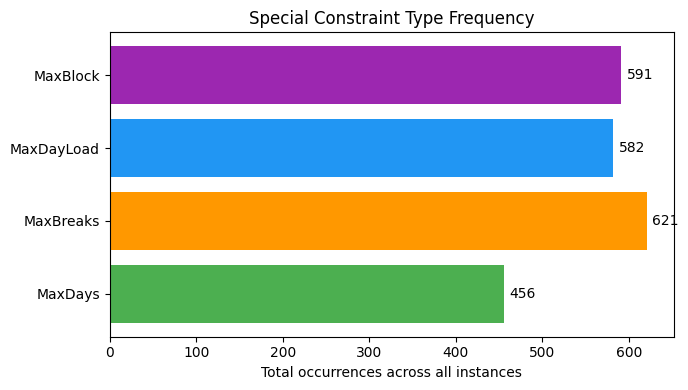

Saved: phase1_constraint_types.png


In [23]:
# ── Constraint type breakdown across all instances ───────────────────────────
from collections import Counter

type_counter = Counter()
for path in instance_paths:
    try:
        r = PSTTReader(path)
        all_cons = (r.distributions.get('hard_constraints', []) +
                    r.distributions.get('soft_constraints', []))
        for c in all_cons:
            if _is_special(c['type']):
                base, _ = _parse_constraint_type(c['type'])
                type_counter[base] += 1
    except:
        pass

fig, ax = plt.subplots(figsize=(7, 4))
labels = list(type_counter.keys())
counts = list(type_counter.values())
bars = ax.barh(labels, counts, color=['#4CAF50','#FF9800','#2196F3','#9C27B0'][:len(labels)])
ax.bar_label(bars, padding=4)
ax.set_xlabel('Total occurrences across all instances')
ax.set_title('Special Constraint Type Frequency')
plt.tight_layout()
plt.savefig('phase1_constraint_types.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: phase1_constraint_types.png')

---
## 7. Summary

All tests passing confirms:

| Test | Scope |
|------|-------|
| `_parse_constraint_type` | Correct parsing of parametric constraint names |
| `_is_special` | Correct identification of the 4 special types |
| `_merge_slots` | Correct slot merging with gap threshold |
| `_UnionFind` | Correct grouping with path compression |
| `_check_max_days/load/breaks/block` | Correct logic for all 4 constraint types |
| Partition (all instances) | Every class in exactly one of {fixed, community, free} |
| Community consistency | Constraints fully covered, communities disjoint |
| `get_fixed_assignments` | Valid (tidx, rid) pairs for single-option classes |
| `check_special_constraints` | Returns bool, handles empty assignments, no exceptions |